In [ ]:
# autores: ai-page.readthedocs.io
# Este cuaderno está basado en el curso statistics and python for financial analysis de la universidad de Hongk kong (Coursera)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
url = "https://raw.githubusercontent.com/it-ces/Datasets/refs/heads/main/housing.csv"
df = pd.read_csv(url, index_col=0)

In [ ]:
# Variables description
# LSTAT (Percentage of people classified as low status)
# INDUS (Proportion of non-retail business acres per town)
# NOX (Nitric oxides concentration)
# RM (Average number of rooms per dwelling)
# MEDV (Median value of homes)

In [ ]:
df.head()

,LSTAT,INDUS,NOX,RM,MEDV
0,4.98,2.31,0.538,6.575,24.0
1,9.14,7.07,0.469,6.421,21.6
2,4.03,7.07,0.469,7.185,34.7
3,2.94,2.18,0.458,6.998,33.4
4,5.33,2.18,0.458,7.147,36.2


# Covarianza

está relacionado con el concepto de covarianza útil para determinar si una de las variables se mueve junto con la otra, en el mismo sentido o en dirección opuesta.



In [ ]:
df.cov() # covarianza muestra si se mueven juntos o no

,LSTAT,INDUS,NOX,RM,MEDV
LSTAT,50.994760,29.580270,0.488946,-3.079741,-48.447538
INDUS,29.580270,47.064442,0.607074,-1.887957,-30.520823
NOX,0.488946,0.607074,0.013428,-0.024603,-0.455412
RM,-3.079741,-1.887957,-0.024603,0.493671,4.493446
MEDV,-48.447538,-30.520823,-0.455412,4.493446,84.586724


# Coeficiente de correlación

El coeficiente de correlación de pearson es un número entre cero y uno que mide el grado de ajuste de los puntos a una línea recta, mientras que el de *spearman* evalue el concepto de monotonicidad.

Usando datos (muestral):
$$ \frac{covariance(x,y)}{std(x)std(y)}$$

el coeficiente es importante dado que está acotado, eso significa que  es un número entre -1 y 1.

In [ ]:
df.corr() # correlación lineal de pearson

,LSTAT,INDUS,NOX,RM,MEDV
LSTAT,1.000000,0.603800,0.590879,-0.613808,-0.737663
INDUS,0.603800,1.000000,0.763651,-0.391676,-0.483725
NOX,0.590879,0.763651,1.000000,-0.302188,-0.427321
RM,-0.613808,-0.391676,-0.302188,1.000000,0.695360
MEDV,-0.737663,-0.483725,-0.427321,0.695360,1.000000


In [ ]:
df.corr(method='spearman') # correlación de spearman

,LSTAT,INDUS,NOX,RM,MEDV
LSTAT,1.000000,0.638747,0.636828,-0.640832,-0.852914
INDUS,0.638747,1.000000,0.791189,-0.415301,-0.578255
NOX,0.636828,0.791189,1.000000,-0.310344,-0.562609
RM,-0.640832,-0.415301,-0.310344,1.000000,0.633576
MEDV,-0.852914,-0.578255,-0.562609,0.633576,1.000000


In [ ]:
# Es muy importante visualizar por si existen patrones no lineal o no monótonos

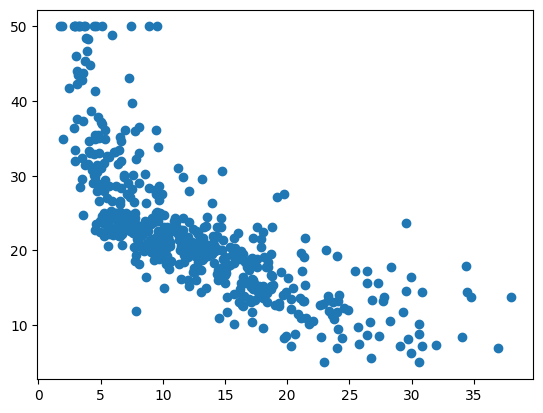

In [ ]:
plt.scatter(df['LSTAT'], df['MEDV'])

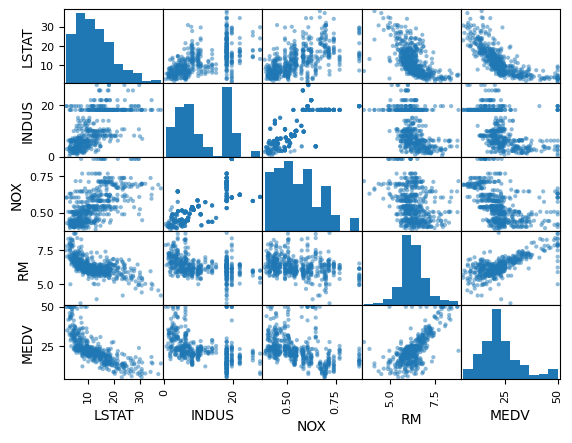

In [ ]:
# veamos una matriz de correlaciones
# importante para detecetr relaciones entre variables!
pd.plotting.scatter_matrix(df);

# Limitación:
Si bien, los coeficientes de correlación nos indican la relación es positiva o negativa, no nos indican  la magnitud de la relación por  aquí es donde aparece el concepto de regresión:

 **Cual es el efecto promedio que tiene el incremento de $(x)$ en una unidad sobre $(y)$**

para ilustrar veamos el ejemplo que se utiliz en el curso:
usamos *RM* para explicar *MEDV*


In [ ]:
df.columns

Index(['LSTAT', 'INDUS', 'NOX', 'RM', 'MEDV'], dtype='object')

# Supuestos sobre la regresión (esto es importante)

tenemos el modelo

$$y = \beta_{0} + \beta_{1} x_{1} + \epsilon $$

Se asume que:




Es importante entender que se usan los datos para obtener:
$\beta_{0},\beta_{1}$ y $\sigma^{2}$ este último cuando es importante hacer inferencia sobre los dos primeros.


## supuestos:

* Linealidad $(y)$ está relacionado linealmente con $(x)$

* Independencia  de los errores es decir $covaraince(\epsilon_{i}, \epsilon_{j}) = 0,  \forall i \neq j$


* $E[\epsilon \mid x] = 0$ las variables explicativas no están relacionadas con los errores (Esto es muy importante!).

* No multicolinealidad perfecta entre las variables explicativas (importante el dummy trap)

* $\epsilon \sim N(0, \sigma^{2})$


Note que el últimos supuesto encierra varias cosas, por ejemplo la normalidad de los errores y la homocedasticidad.



Estos supuestos deben ser validados para garantizar propiedades deseables sobre las estimaciones de $\beta_{0}$ y $\beta_{1}$ como su sesgadez es decir que efectivamente el valor *muestral* concuerde con el poblacional.

# Que buscamos exactamente

minimizar los errores:
$$SSE = \sum e_{i}^{2} = \sum (y_{i} - prediction(y_{i}))^{2}  $$
Buscamos la línea que minimize la suma de errores al cuadrado.


In [ ]:
# OLS (Ordinary Least Squares) - MCO (Mínimos Cuadrados Ordinarios)
import statsmodels.formula.api as smf

In [ ]:
mod = smf.ols(formula='MEDV ~ RM', data=df)
res = mod.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.484
Model:                            OLS   Adj. R-squared:                  0.483
Method:                 Least Squares   F-statistic:                     471.8
Date:                Tue, 13 May 2025   Prob (F-statistic):           2.49e-74
Time:                        20:04:32   Log-Likelihood:                -1673.1
No. Observations:                 506   AIC:                             3350.
Df Residuals:                     504   BIC:                             3359.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -34.6706      2.650    -13.084      0.0

Importante note el coeficiente asociado con la variable *RM*, es la magnitud del efecto.

# Información importante para extraer de la tabla anterior

* $R^{2}$
* t
* $P > \mid t \mid$


$R^{2}$ expresa la variabilidad explicada por el modelo es un número entre cero y uno

$t$ es el estadístico de prueba para la hipótesis de que

$$ H_{0} : \beta_{i} = 0 $$  

y el $P$ valor indica la probabilidad de observar ese estadístico de prueba suponiendo que la hipótesis nula es cierta.

# Diagnostico
Es importante verificar si se cumplen los supuestos.


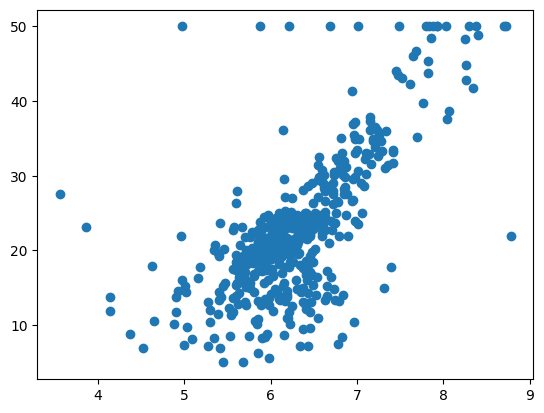

In [ ]:
# linealidad con gráfica
plt.scatter(df['RM'],df['MEDV'])

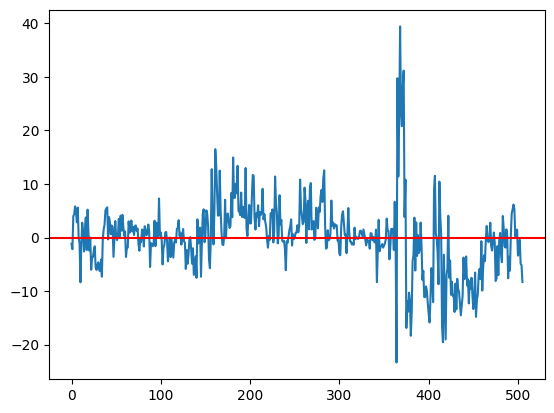

In [ ]:
# observed error are independent
# no correlación serial en los errores
# we can make durbin-watson
residuals = res.resid
plt.plot(residuals)
plt.axhline(y=0, color='red')

# Durbin-watson
mirar que en la tabla de resumen aparece durbin-watson,
si $d$ está entre 1.5 y 2.5 entonces está bien, de lo contrairo hay indicios de autocorrelación.

Para este ejemplo, $d=0.68$ por lo que este supuesto no se cumple.

# Normalidad

recuerde el supuesto de que $e \sim N(0, \sigma^{2})$. aquí podemos usar el gráfico QQ.


si los datos son normales entonces deben caer sobre línea de 45 grados.

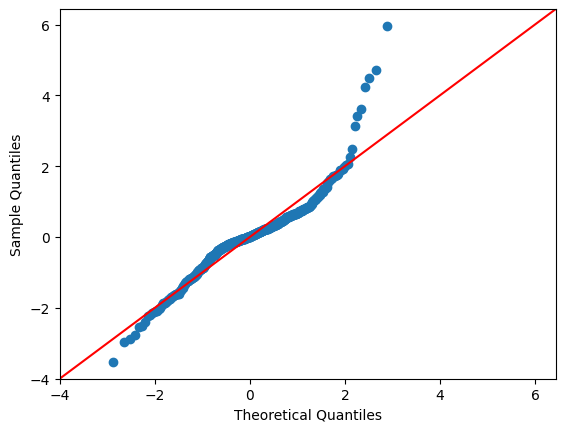

In [ ]:
import statsmodels.api as sm
residuals_z = res.resid_pearson
sm.qqplot(residuals_z, line='45');

In [ ]:
# también podríamos usar un test..
from scipy import stats
stats.shapiro(residuals_z) # en este caso cuando p>0.05 entonces es normal en el  caso contrario no es normal
# para este ejemplo el supuesto de normalidad no se cumple!.

ShapiroResult(statistic=np.float64(0.9204628932599064), pvalue=np.float64(1.0877415191901464e-15))

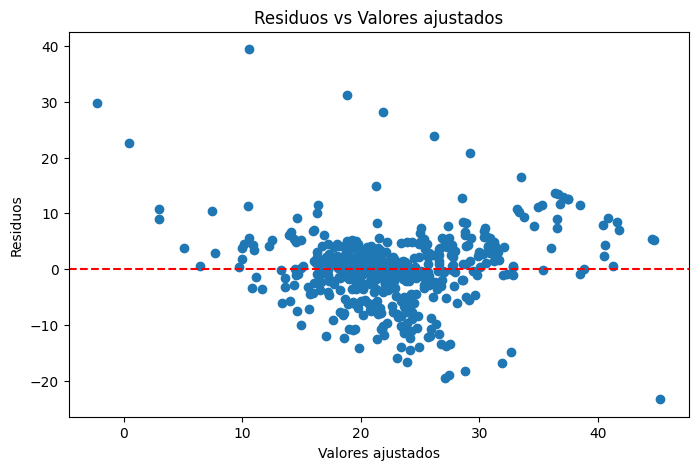

In [ ]:
# Homocedasticidad


# Valores ajustados y residuos del modelo
fitted_vals = res.fittedvalues
residuals = res.resid

# Gráfico
plt.figure(figsize=(8, 5))
plt.scatter(x=fitted_vals, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Valores ajustados")
plt.ylabel("Residuos")
plt.title("Residuos vs Valores ajustados")
plt.show()
# hay algunos test estadístico como breush-pagan o prueba de white.
# no hay embudos o cosas así graficamente

In [ ]:
from statsmodels.stats.diagnostic import het_breuschpagan
residuos = res.resid
res.model.exog
bp_test = het_breuschpagan(residuos, X)
bp_test[-1] # este es el valor de P
# la hipótesis nula del test es la homocedasticidad por lo que este modelo si cumple con el supuesto

np.float64(0.9335474998849156)

si los supestos no se cumplen no puedo estar seguro de las inferencias!